In [612]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from graphviz import Digraph

In [613]:
def f(x):
    return 3*x**2 - 4*x + 5


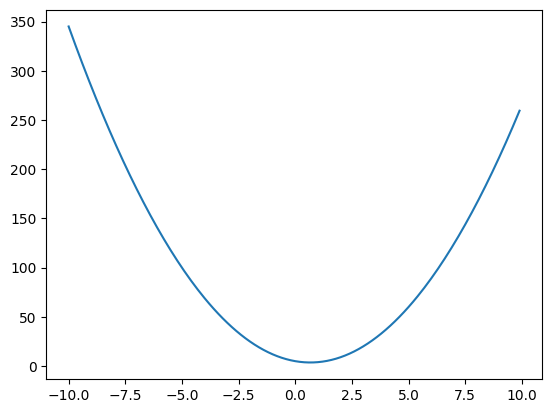

In [614]:
xs = np.arange(-10, 10, 0.1)
ys = f(xs)
plt.plot(xs, ys)

In [615]:
h = 0.0001
x = -3.0
(f(x + h) - f(x)) / h

-21.999700000066014

In [616]:
# input
h = 0.00000001
a = 3
b = 2
c = 5

d = a * b + c
a += h
d1 = a*b + c

print('d', d)
print('d1', d1)
print('slope', (d1 - d)/h)

d 11
d1 11.00000002
slope 1.999999987845058


In [617]:
class Value:
    def __init__(self, data, _prev = (), _op = '', label = ''):
        self.data = data
        self._prev = set(_prev)
        self._op = _op
        self.label = label
        self.grad = 0.0
        self._backward = lambda:None
    
    def __repr__(self):
        return f"Value(data= {self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out
    
    def __radd__(self, other):
        return self + other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def __rmul__(self, other):
        return self * other

    def __truediv__(self, other):
        return self * (other ** -1)
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only int and float can be powed"
        out = Value(self.data ** other, (self, ), f'**{other}')

        def _backward():
            self.grad += other * self.data ** (other - 1) * out.grad
        out._backward = _backward
        return out

    def __neg__(self):
        return self * -1
    
    def __sub__(self, other):
        return self + (-other)
    
    def tanh(self):
        n = self.data
        out = (math.exp(2*n)-1) / (math.exp(2*n)+1)
        o = Value(out, (self, ), 'tanh')
        def _backward():
            self.grad += (1 - o.data**2) * o.grad
        o._backward = _backward
        return o
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ),'exp')
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out
    
    def backward(self):
        topo = []
        visited = set()
        def build_root(input):
            if input in visited:
                return None
            visited.add(input)
            for i in input._prev:
                build_root(i)
            topo.append(input)
        build_root(self)
        

        self.grad = 1.0
        for n in reversed(topo):
            #print(n.data)
            n._backward()

In [618]:
a = Value(2.0)
b = a - 1

b.backward()


In [619]:
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{label %s |data %.4f| grad %.4f}" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

In [620]:
#input 
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

#weight
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

#bias
b = Value(6.8813735870195432, label='b')

x1w1 = x1*w1; x1w1.label='x1w1'
x2w2 = x2*w2; x2w2.label='x2w2'
x1w1x2w2 = x1w1+x2w2; x1w1x2w2.label='x1w1+x2w2' 
n = x1w1x2w2 + b; n.label ='n'
o = n.tanh(); o.label = 'o'


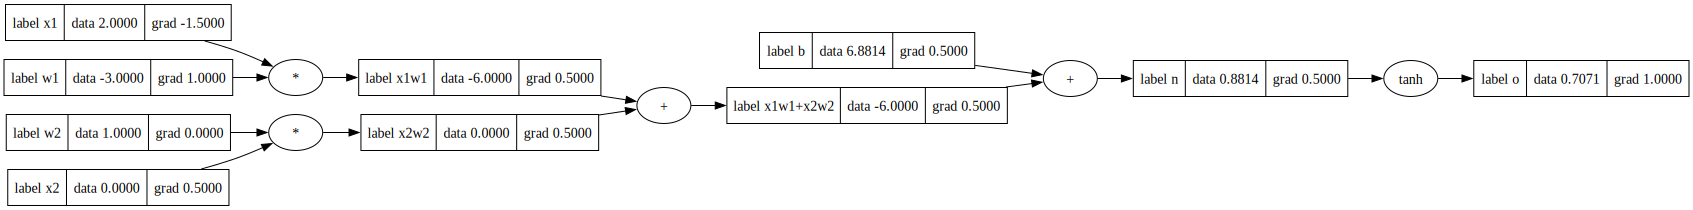

In [621]:
o.backward()
draw_dot(o)

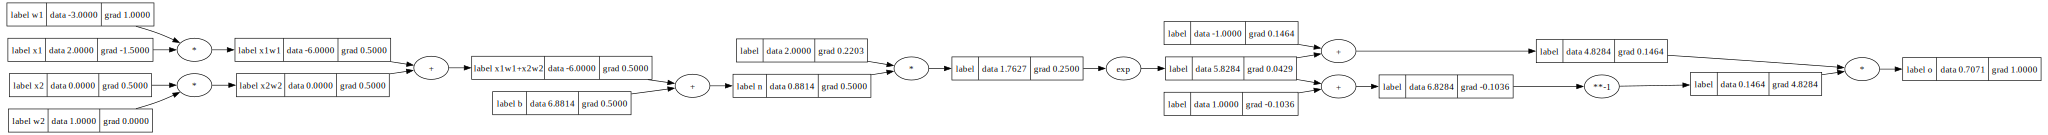

In [622]:
#input 
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

#weight
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

#bias
b = Value(6.8813735870195432, label='b')

x1w1 = x1*w1; x1w1.label='x1w1'
x2w2 = x2*w2; x2w2.label='x2w2'
x1w1x2w2 = x1w1+x2w2; x1w1x2w2.label='x1w1+x2w2' 
n = x1w1x2w2 + b; n.label ='n'
# ----
e = (2*n).exp()
o = (e - 1)/(e + 1)
# ----
o.label = 'o'
o.backward()
draw_dot(o)

接下来是pytorch版本


In [623]:
import torch

x1 = torch.Tensor([2.0]).double();               x1.requires_grad = True
x2 = torch.Tensor([0.0]).double();               x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double();              w1.requires_grad = True
w2 = torch.Tensor([1.0]).double();               w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())


0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [624]:
import random
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        #w * x + b
        act =  sum([w*x for w,x in zip(self.w, x)], self.b)
        out = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]
    
class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
    
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for l in self.layers for p in l.parameters()]
        

In [625]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)
n.parameters()

[Value(data= -0.6039041465809696),
 Value(data= 0.980325952501115),
 Value(data= 0.4162290543709015),
 Value(data= 0.010775291985542168),
 Value(data= 0.5277327335620388),
 Value(data= -0.14965920255058407),
 Value(data= -0.27387552714567076),
 Value(data= 0.8282929686524756),
 Value(data= 0.14090414503819026),
 Value(data= -0.8938492423420796),
 Value(data= 0.9912206437315141),
 Value(data= 0.13437786067153867),
 Value(data= -0.17447332995781872),
 Value(data= 0.9655861326017359),
 Value(data= 0.07688707977109965),
 Value(data= -0.9048795234638551),
 Value(data= 0.010342165935392833),
 Value(data= 0.10023832282054035),
 Value(data= -0.6507351216025146),
 Value(data= 0.8881859961544643),
 Value(data= 0.8132362495930232),
 Value(data= -0.42587617885473295),
 Value(data= -0.4895382425807002),
 Value(data= 0.9976028458760353),
 Value(data= 0.12453379005150356),
 Value(data= 0.3128385875497768),
 Value(data= 0.9631399429332175),
 Value(data= -0.32834827929293375),
 Value(data= -0.776078605

In [626]:


xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.2, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]

In [627]:
k = 1
while(1):
    ypred = [n(x) for x in xs]
    loss = sum([(yout - ypre)**2 for ypre, yout in zip(ys, ypred)])

    for p in n.parameters():
        p.grad = 0.0
    loss.backward()

    for p in n.parameters():
        p.data += -0.1 * p.grad

    k += 1
    print(k, loss.data)

    if(loss.data < 0.0001):
        break

2 5.667349483666598
3 3.1223641248323766
4 0.6300904832705535
5 0.26999244039743164
6 0.16559861548961335
7 0.11958487511826857
8 0.09286242336371223
9 0.07553888198131262
10 0.06345909124110231
11 0.054585830714402844
12 0.047808672155122994
13 0.04247314769588166
14 0.038169583846064246
15 0.03462896735022945
16 0.03166762924537219
17 0.029156045160423513
18 0.02700034570579108
19 0.025130894677543696
20 0.02349497937111826
21 0.0220519876986483
22 0.020770140388978724
23 0.019624224503540517
24 0.01859398854788282
25 0.017662984853237838
26 0.016817720598802387
27 0.016047025780252397
28 0.015341576239650042
29 0.014693529220491167
30 0.014096241720309956
31 0.013544050546390074
32 0.013032098895537386
33 0.012556198393935031
34 0.012112718436019165
35 0.011698496735782717
36 0.011310766504255793
37 0.010947096764207371
38 0.010605343124043215
39 0.010283606938040599
40 0.009980201235820201
41 0.009693622150151461
42 0.009422524837291456
43 0.009165703088615348
44 0.0089220719912758

In [628]:
ypred

[Value(data= 0.9959805063382674),
 Value(data= -0.9961048339559424),
 Value(data= -0.9937466104820653),
 Value(data= 0.9945650724235675)]